# vulntool — quick start

**Which species are most at risk of disappearing locally, and which are safer than their rarity suggests.**

Rarity on its own is a poor guide. Two species can be equally uncommon and face very different odds: one scattered thinly across the whole plot is exposed everywhere at once, while one growing in a few dense clumps holds enough ground somewhere to persist. `W_alpha` measures that difference — **the more negative, the better protected**.

## 1. Load and inspect a census

The input is a CSV with one row per patch: species names along the top, a patch label in the first column, and how much of each species that patch holds in the cells.

In [1]:
import pandas as pd
census = pd.read_csv('example_data.csv')
census.head()

,patch,Aglaia,Shorea,Dipterocarpus,Macaranga,Ficus,Xerospermum,Knema,Gironniera
0,P00,0.0,0.0,19.1,4.3,10.4,0.0,8.0,0.0
1,P01,32.7,0.0,3.1,0.0,22.8,1.8,10.1,0.0
2,P02,23.0,101.7,46.6,0.0,23.8,0.0,11.5,62.3
3,P03,21.1,0.0,4.6,0.0,21.2,13.6,22.8,0.0
4,P04,35.0,1.8,28.7,0.0,26.2,0.0,14.3,0.0


## 2. Work out the vulnerabilities

One call does the whole thing: pick which species to include, work out how full a patch can get and how each species varies from patch to patch, and turn that into a vulnerability for each.

In [2]:
from vulntool import compute_vulnerability
result = compute_vulnerability('example_data.csv')
print(result)
result.table

VulnerabilityResult(species=7, M0=368.9, cv_xs=0.3632, Delta=-0.2737)


/home/davide/Work/MyPapers/Submitted-Vulnerability-BerNicXX/vulnerability-tool/src/vulntool/theory.py:75: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  res, _ = integrate.quad(


,species,abundance,p_alpha,betabar,delta,W_alpha
0,Ficus,1264.6,0.057134,51.855541,3.942762,-0.402295
1,Aglaia,1194.7,0.053976,38.984109,3.245660,-0.515814
2,Dipterocarpus,818.8,0.036993,11.973755,0.926823,-1.468101
3,Shorea,659.8,0.029809,7.188058,0.465620,-2.272506
4,Knema,537.2,0.024270,41.826828,1.671667,-0.484923
5,Xerospermum,481.1,0.021736,20.314697,0.935630,-0.920116
6,Gironniera,370.3,0.016730,19.922051,0.810536,-0.936246


`result.M0` is how much one patch holds when full — fitted from the data, never set by you. `result.cv_xs` says how unequal the species are in typical abundance, and `result.selection` records which species were kept and which were dropped.

In [3]:
result.M0, result.cv_xs, result.selection

(368.90000000000003,
 0.36320005246374104,
 {'S_total': 8,
  'S_after_frac': 7,
  'S_after_zero': 7,
  'removed_by_frac': 1,
  'removed_by_zero': 0,
  'frac_keep': 0.95,
  'max_zero_frac': 0.9})

## 3. Plot vulnerability against abundance

This is the pairing worth looking at. Species at the left-hand edge are the rare ones; how high or low they sit says whether being rare is actually costing them. The clumpy species — small `delta` — sit low, and are the ones holding on despite being uncommon.

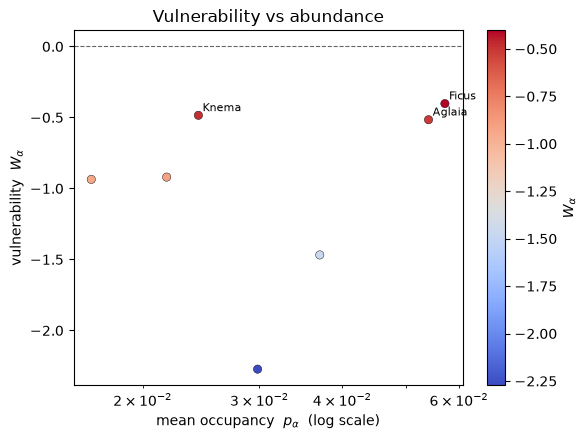

In [4]:
from vulntool import plot_vulnerability
ax = plot_vulnerability(result, annotate=3)

## 4. Save the results
```python
result.to_csv('vulnerability_results.csv')
```

### Including more species
By default the commonest species are kept, down to where they account for 95% of all individuals, and anything missing from more than 90% of patches is dropped — a species found in a handful of patches gives the model almost nothing to work with. To fit every species regardless:
```python
compute_vulnerability('example_data.csv', frac_keep=1.0, max_zero_frac=1.0)
```